In [6]:
!pip install -q ultralytics opencv-python matplotlib pyyaml

from pathlib import Path
import zipfile
import shutil

ZIP_PATH = Path("/content/yolo_pose_70_20_10.zip")  # change if your zip name differs
EXTRACT_DIR = Path("/content/grip_pose_dataset")

if not ZIP_PATH.exists():
    raise FileNotFoundError(f"Upload your zip first. Not found: {ZIP_PATH}")

if EXTRACT_DIR.exists():
    shutil.rmtree(EXTRACT_DIR)

EXTRACT_DIR.mkdir(parents=True, exist_ok=True)

with zipfile.ZipFile(ZIP_PATH, "r") as z:
    z.extractall(EXTRACT_DIR)

print("Extracted to:", EXTRACT_DIR)

data_yaml_files = list(EXTRACT_DIR.rglob("data.yaml"))

print("Found data.yaml files:")
for p in data_yaml_files:
    print(p)

if len(data_yaml_files) == 0:
    raise RuntimeError("No data.yaml found inside zip.")

DATA_YAML = data_yaml_files[0]
print("Using:", DATA_YAML)

Extracted to: /content/grip_pose_dataset
Found data.yaml files:
/content/grip_pose_dataset/yolo_pose_70_20_10/data.yaml
Using: /content/grip_pose_dataset/yolo_pose_70_20_10/data.yaml


In [7]:
from pathlib import Path
import yaml

DATA_YAML = Path(DATA_YAML)

with open(DATA_YAML, "r", encoding="utf-8") as f:
    data = yaml.safe_load(f)

print(data)

dataset_root = DATA_YAML.parent

for split in ["train", "val", "test"]:
    img_dir = dataset_root / "images" / split
    lbl_dir = dataset_root / "labels" / split

    imgs = list(img_dir.glob("*"))
    labels = list(lbl_dir.glob("*.txt"))

    print(f"\n{split.upper()}")
    print("Images:", len(imgs))
    print("Labels:", len(labels))

    if labels:
        sample = labels[0]
        line = sample.read_text().splitlines()[0]
        parts = line.split()
        print("Sample label:", sample.name)
        print("Values in one line:", len(parts))
        print("Expected for 7 keypoints:", 26)

{'path': 'D:/GRIP_Yolo_pose/YOLO_pose_MVP_dataset/yolo_pose_70_20_10', 'train': 'images/train', 'val': 'images/val', 'test': 'images/test', 'kpt_shape': [7, 3], 'flip_idx': [0, 1, 2, 3, 4, 5, 6], 'names': {0: 'glove'}}

TRAIN
Images: 36
Labels: 36
Sample label: Raw_dataset_Left_glove_raw_f0004200_s00084.txt
Values in one line: 26
Expected for 7 keypoints: 26

VAL
Images: 10
Labels: 10
Sample label: Raw_dataset_Left_glove_raw_f0000650_s00013.txt
Values in one line: 26
Expected for 7 keypoints: 26

TEST
Images: 6
Labels: 6
Sample label: Raw_dataset_Right_glove_raw_1_f0001050_s00021.txt
Values in one line: 26
Expected for 7 keypoints: 26


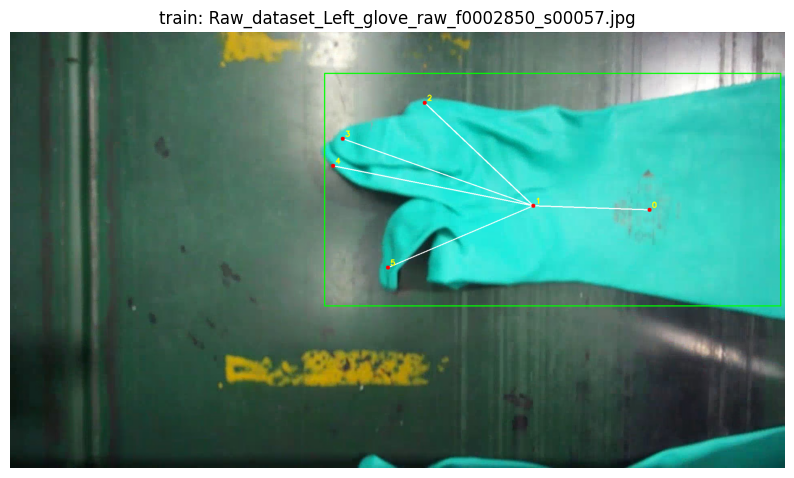

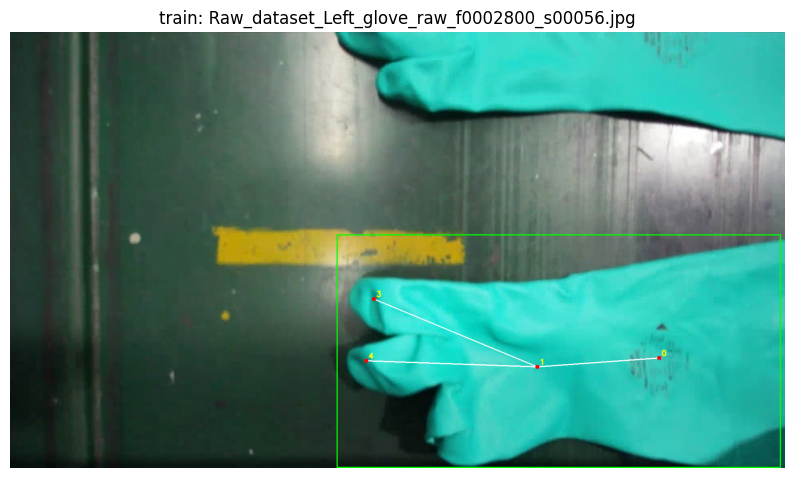

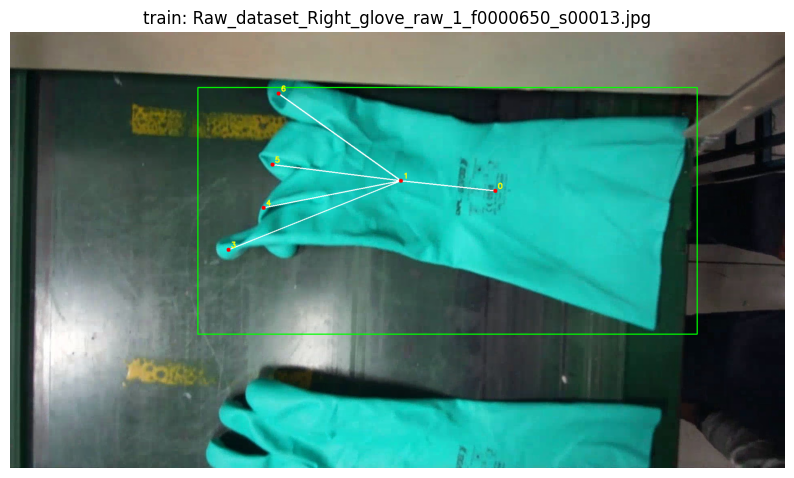

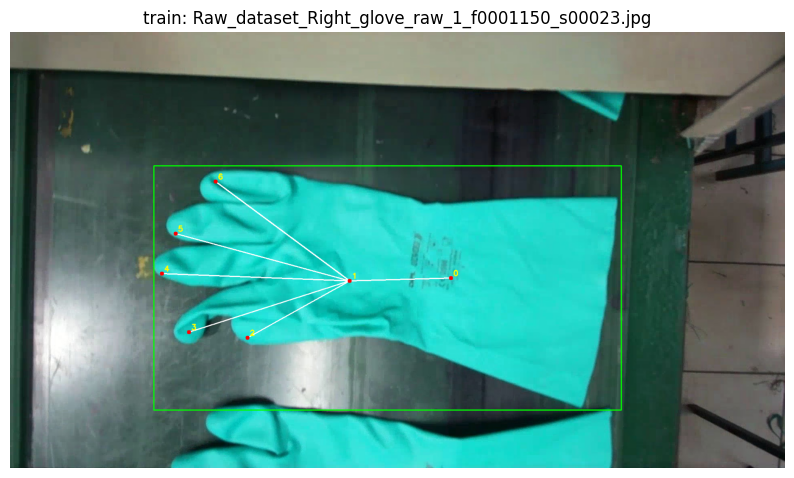

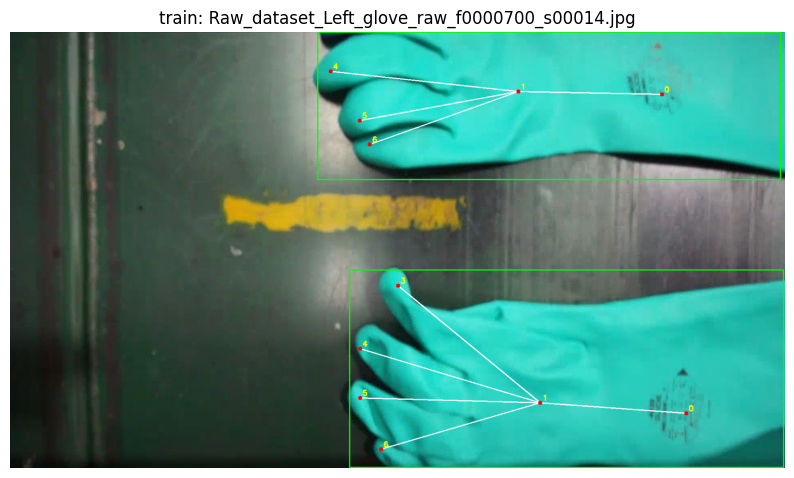

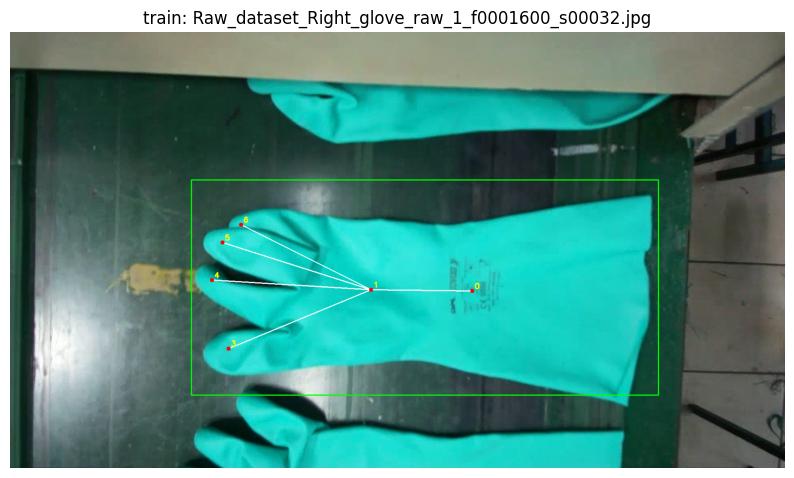

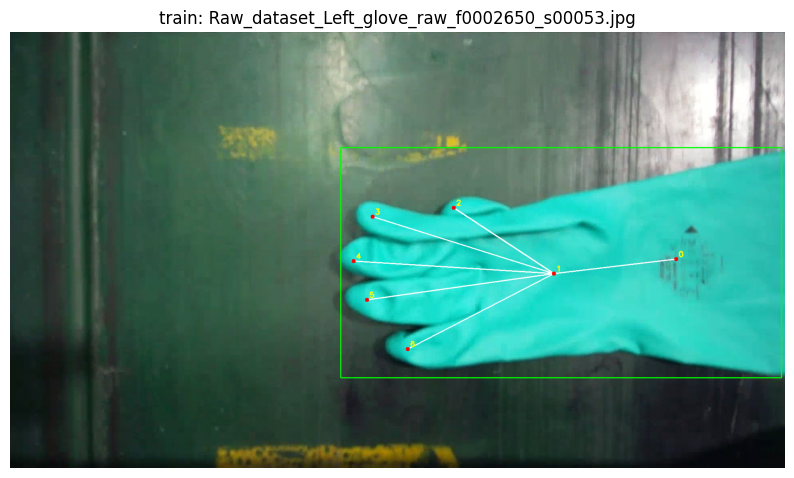

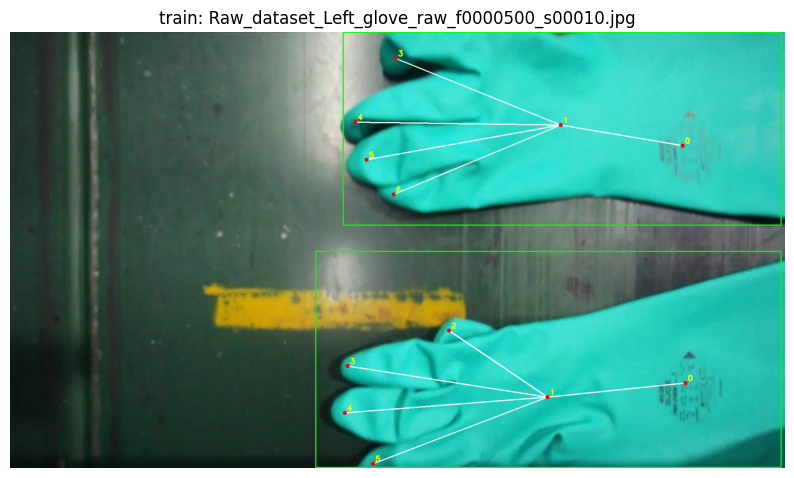

In [8]:
import cv2
import matplotlib.pyplot as plt
import random
from pathlib import Path

dataset_root = DATA_YAML.parent

KEYPOINT_NAMES = [
    "wrist_center",
    "palm_center",
    "thumb_tip",
    "index_tip",
    "middle_tip",
    "ring_tip",
    "pinky_tip",
]

SKELETON_EDGES = [
    (0, 1),
    (1, 2),
    (1, 3),
    (1, 4),
    (1, 5),
    (1, 6),
]

def find_image_for_label(label_path, img_dir):
    for ext in [".jpg", ".jpeg", ".png", ".bmp", ".webp"]:
        img_path = img_dir / f"{label_path.stem}{ext}"
        if img_path.exists():
            return img_path
    return None

def show_pose_sample(split="train", n=8):
    img_dir = dataset_root / "images" / split
    lbl_dir = dataset_root / "labels" / split

    labels = list(lbl_dir.glob("*.txt"))
    random.shuffle(labels)

    for label_path in labels[:n]:
        img_path = find_image_for_label(label_path, img_dir)

        if img_path is None:
            print("No image for:", label_path.name)
            continue

        img = cv2.imread(str(img_path))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        h, w = img.shape[:2]

        for line in label_path.read_text().splitlines():
            parts = line.split()

            if len(parts) != 26:
                print("Bad label:", label_path.name, "values:", len(parts))
                continue

            cls = int(float(parts[0]))
            xc, yc, bw, bh = map(float, parts[1:5])

            x1 = int((xc - bw / 2) * w)
            y1 = int((yc - bh / 2) * h)
            x2 = int((xc + bw / 2) * w)
            y2 = int((yc + bh / 2) * h)

            cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), 2)

            kps = []
            kp_values = parts[5:]

            for i in range(7):
                x = float(kp_values[i * 3]) * w
                y = float(kp_values[i * 3 + 1]) * h
                v = int(float(kp_values[i * 3 + 2]))
                kps.append((x, y, v))

            for a, b in SKELETON_EDGES:
                if kps[a][2] > 0 and kps[b][2] > 0:
                    ax, ay, _ = kps[a]
                    bx, by, _ = kps[b]
                    cv2.line(img, (int(ax), int(ay)), (int(bx), int(by)), (255, 255, 255), 2)

            for i, (x, y, v) in enumerate(kps):
                if v > 0:
                    cv2.circle(img, (int(x), int(y)), 5, (255, 0, 0), -1)
                    cv2.putText(img, str(i), (int(x) + 6, int(y) - 6),
                                cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 0), 2)

        plt.figure(figsize=(10, 7))
        plt.imshow(img)
        plt.axis("off")
        plt.title(f"{split}: {img_path.name}")
        plt.show()

show_pose_sample("train", n=8)

In [10]:
from pathlib import Path
import yaml

# DATA_YAML should already be found from Cell 1
DATA_YAML = Path("/content/grip_pose_dataset/yolo_pose_70_20_10/data.yaml")

if not DATA_YAML.exists():
    # fallback: search automatically
    found = list(Path("/content/grip_pose_dataset").rglob("data.yaml"))
    if not found:
        raise FileNotFoundError("No data.yaml found.")
    DATA_YAML = found[0]

print("Using data.yaml:", DATA_YAML)

with open(DATA_YAML, "r", encoding="utf-8") as f:
    data = yaml.safe_load(f)

print("\nOld data.yaml:")
print(data)

# Fix path for Colab
data["path"] = str(DATA_YAML.parent)

# Make sure split paths are relative to data["path"]
data["train"] = "images/train"
data["val"] = "images/val"
data["test"] = "images/test"

# Make sure pose settings are correct
data["kpt_shape"] = [7, 3]
data["flip_idx"] = [0, 1, 2, 3, 4, 5, 6]
data["names"] = {0: "glove"}

with open(DATA_YAML, "w", encoding="utf-8") as f:
    yaml.safe_dump(data, f, sort_keys=False)

print("\nFixed data.yaml:")
with open(DATA_YAML, "r", encoding="utf-8") as f:
    print(f.read())

# Verify folders exist
dataset_root = DATA_YAML.parent

for split in ["train", "val", "test"]:
    img_dir = dataset_root / "images" / split
    lbl_dir = dataset_root / "labels" / split

    print(f"\n{split.upper()}")
    print("Image dir:", img_dir, "exists:", img_dir.exists())
    print("Label dir:", lbl_dir, "exists:", lbl_dir.exists())
    print("Images:", len(list(img_dir.glob("*"))) if img_dir.exists() else 0)
    print("Labels:", len(list(lbl_dir.glob("*.txt"))) if lbl_dir.exists() else 0)

Using data.yaml: /content/grip_pose_dataset/yolo_pose_70_20_10/data.yaml

Old data.yaml:
{'path': 'D:/GRIP_Yolo_pose/YOLO_pose_MVP_dataset/yolo_pose_70_20_10', 'train': 'images/train', 'val': 'images/val', 'test': 'images/test', 'kpt_shape': [7, 3], 'flip_idx': [0, 1, 2, 3, 4, 5, 6], 'names': {0: 'glove'}}

Fixed data.yaml:
path: /content/grip_pose_dataset/yolo_pose_70_20_10
train: images/train
val: images/val
test: images/test
kpt_shape:
- 7
- 3
flip_idx:
- 0
- 1
- 2
- 3
- 4
- 5
- 6
names:
  0: glove


TRAIN
Image dir: /content/grip_pose_dataset/yolo_pose_70_20_10/images/train exists: True
Label dir: /content/grip_pose_dataset/yolo_pose_70_20_10/labels/train exists: True
Images: 36
Labels: 36

VAL
Image dir: /content/grip_pose_dataset/yolo_pose_70_20_10/images/val exists: True
Label dir: /content/grip_pose_dataset/yolo_pose_70_20_10/labels/val exists: True
Images: 10
Labels: 10

TEST
Image dir: /content/grip_pose_dataset/yolo_pose_70_20_10/images/test exists: True
Label dir: /content/

In [11]:
from ultralytics import YOLO
import torch
from pathlib import Path
import shutil

print("CUDA available:", torch.cuda.is_available())
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")

DATA_YAML = str(DATA_YAML)

PROJECT_DIR = "/content/grip_pose_runs"
RUN_NAME = "grip_yolo_pose_mvp_test"

RUN_DIR = Path(PROJECT_DIR) / RUN_NAME

if RUN_DIR.exists():
    shutil.rmtree(RUN_DIR)

# Try YOLO26 pose first. If unavailable, change to yolo11s-pose.pt.
model = YOLO("yolo26s-pose.pt")

results = model.train(
    data=DATA_YAML,
    epochs=80,
    imgsz=768,
    batch=8,
    patience=20,
    device=0,
    workers=2,
    cache=True,
    amp=True,

    # Very important for this pose geometry task
    fliplr=0.0,
    flipud=0.0,

    # Safe mild augmentation
    degrees=10.0,
    translate=0.04,
    scale=0.08,
    shear=1.0,
    perspective=0.0,

    hsv_h=0.005,
    hsv_s=0.10,
    hsv_v=0.12,

    mosaic=0.0,
    mixup=0.0,
    copy_paste=0.0,
    erasing=0.0,

    optimizer="AdamW",
    lr0=0.001,
    weight_decay=0.0005,
    cos_lr=True,

    project=PROJECT_DIR,
    name=RUN_NAME,
    plots=True,
    save=True,
    save_period=10
)

print("Best model:")
print(RUN_DIR / "weights" / "best.pt")

CUDA available: True
GPU: Tesla T4
Ultralytics 8.4.81 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=True, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/content/grip_pose_dataset/yolo_pose_70_20_10/data.yaml, degrees=10.0, deterministic=True, device=0, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=80, erasing=0.0, exist_ok=False, fliplr=0.0, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.005, hsv_s=0.1, hsv_v=0.12, imgsz=768, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26s-pose.pt, momentum=0.937, mosaic=0.0, multi_scale=0.0, name=grip_yolo_pose_mvp_test, nbs=64, n

In [13]:
# CELL 5 - Predict test images with trained YOLO-pose model

from ultralytics import YOLO
from pathlib import Path

BEST_MODEL = Path("/content/grip_pose_runs/grip_yolo_pose_mvp_test/weights/best.pt")

if not BEST_MODEL.exists():
    raise FileNotFoundError(f"Model not found: {BEST_MODEL}")

model = YOLO(str(BEST_MODEL))

# Convert DATA_YAML back to Path
DATA_YAML_PATH = Path(DATA_YAML)

dataset_root = DATA_YAML_PATH.parent
test_dir = dataset_root / "images" / "test"

print("Best model:", BEST_MODEL)
print("Dataset root:", dataset_root)
print("Test image folder:", test_dir)
print("Test folder exists:", test_dir.exists())
print("Test images:", len(list(test_dir.glob('*'))))

if not test_dir.exists():
    raise FileNotFoundError(f"Test image folder not found: {test_dir}")

results = model.predict(
    source=str(test_dir),
    imgsz=768,
    conf=0.20,
    save=True,
    project="/content/grip_pose_predictions",
    name="mvp_test_predictions"
)

print("\nPredictions saved to:")
print("/content/grip_pose_predictions/mvp_test_predictions")

Best model: /content/grip_pose_runs/grip_yolo_pose_mvp_test/weights/best.pt
Dataset root: /content/grip_pose_dataset/yolo_pose_70_20_10
Test image folder: /content/grip_pose_dataset/yolo_pose_70_20_10/images/test
Test folder exists: True
Test images: 6

image 1/6 /content/grip_pose_dataset/yolo_pose_70_20_10/images/test/Raw_dataset_Left_glove_raw_f0000450_s00009.jpg: 448x768 1 glove, 67.1ms
image 2/6 /content/grip_pose_dataset/yolo_pose_70_20_10/images/test/Raw_dataset_Left_glove_raw_f0000600_s00012.jpg: 448x768 1 glove, 16.9ms
image 3/6 /content/grip_pose_dataset/yolo_pose_70_20_10/images/test/Raw_dataset_Left_glove_raw_f0004100_s00082.jpg: 448x768 1 glove, 16.9ms
image 4/6 /content/grip_pose_dataset/yolo_pose_70_20_10/images/test/Raw_dataset_Right_glove_raw_1_f0000500_s00010.jpg: 448x768 1 glove, 16.9ms
image 5/6 /content/grip_pose_dataset/yolo_pose_70_20_10/images/test/Raw_dataset_Right_glove_raw_1_f0001050_s00021.jpg: 448x768 2 gloves, 16.9ms
image 6/6 /content/grip_pose_dataset/yo

Prediction images: 6


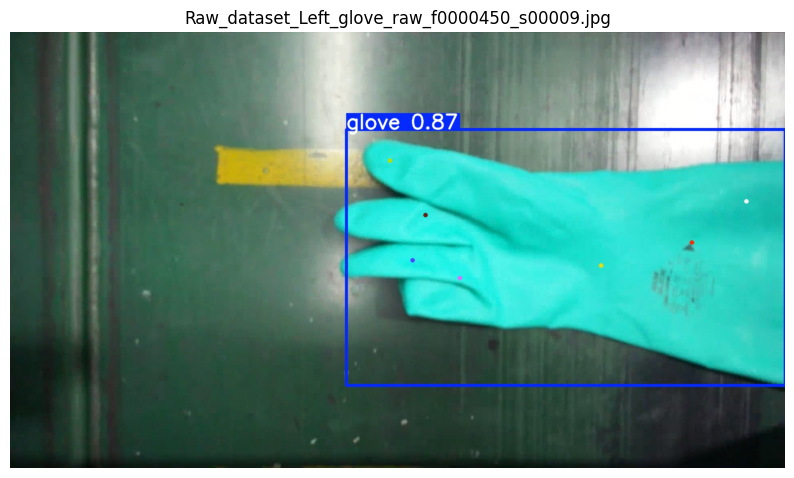

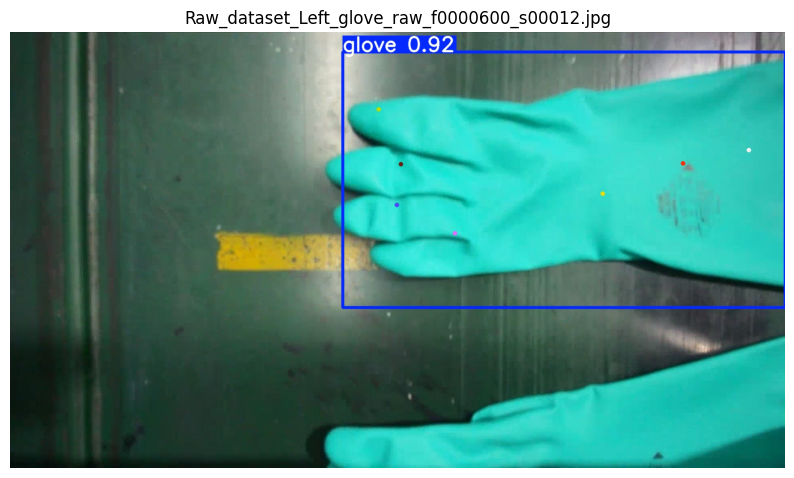

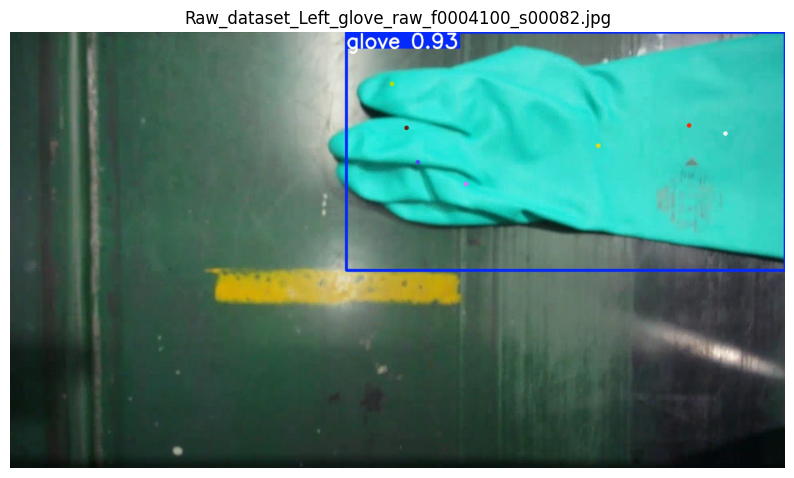

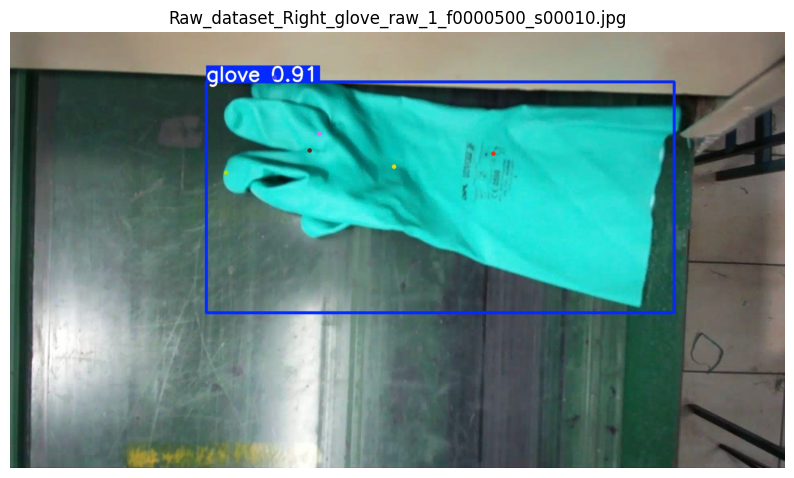

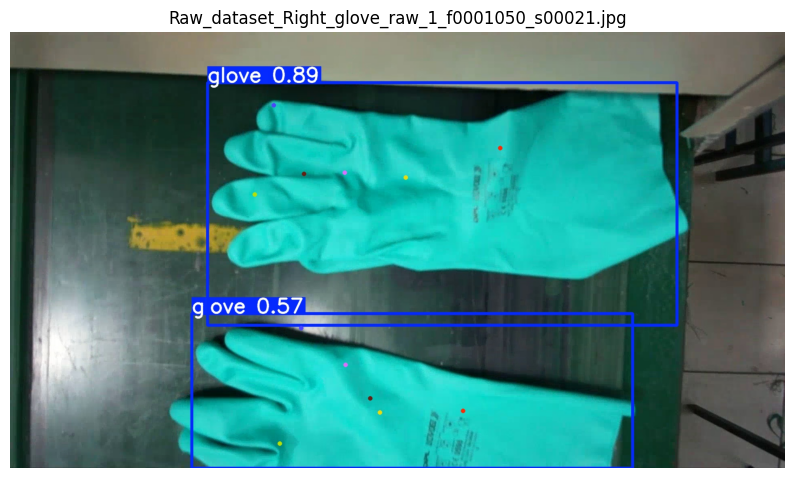

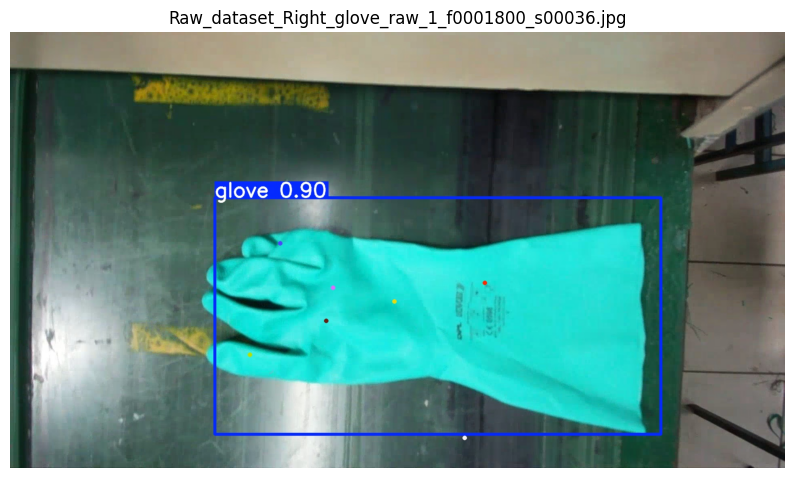

In [14]:
# CELL 6 - Display YOLO-pose predictions

from pathlib import Path
import matplotlib.pyplot as plt
import cv2

pred_dir = Path("/content/grip_pose_predictions/mvp_test_predictions")

pred_imgs = sorted([
    p for p in pred_dir.glob("*")
    if p.suffix.lower() in [".jpg", ".jpeg", ".png", ".bmp", ".webp"]
])

print("Prediction images:", len(pred_imgs))

for p in pred_imgs:
    img = cv2.imread(str(p))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(10, 7))
    plt.imshow(img)
    plt.axis("off")
    plt.title(p.name)
    plt.show()